# Quantvesting — 60-Month SIP Backtest

## Monthly SIP comparison across three approaches

This notebook adapts the original `06_QUANTVESTING_BACKTEST.ipynb` into a **₹2.5 lakh/month SIP backtest for 60 months**.

It compares:

1. **Quantvesting Strategy SIP** — monthly capital is added to cash and deployed into the best currently eligible Quantvesting opportunities, using the original conviction + ATH-gap logic, while respecting the 3% corpus cap and the original frozen-ATH exit rule.
2. **Nifty 50 SIP** — each monthly contribution buys the Nifty 50 index at the first available trading-day open. The 3% *single-scrip* cap is not applicable because the Nifty index is the instrument rather than an individual scrip.
3. **Quantvesting Universe — Equal-Weight SIP** — each monthly contribution is allocated equally across the securities in `signals.csv`, with any amount that cannot be deployed because of the 3% per-scrip cap remaining as cash.

### Important definition of “most lucrative opportunity”

This notebook does **not** use future monthly returns to decide where the SIP went. That would introduce look-ahead bias.

For the Quantvesting strategy, the monthly SIP is allocated to the highest-priority **currently eligible** candidates based on the same ex-ante information used by the original strategy: **conviction rank first, then larger ATH Gap**. If the first candidate cannot absorb the entire SIP because of the 3% corpus cap, the remainder is allocated to the next eligible candidate, and so on.

For the equal-weight universe, “opportunity” is deliberately kept consistent with the strategy definition: the monthly contribution is split equally across the universe, not retrospectively concentrated into the month's winner.

The monthly contribution is added to the portfolio first. The 3% position limit is then calculated against the **total corpus immediately after that month's SIP contribution**. This makes the rule well-defined even in month 1, when the starting corpus is zero.


In [1]:
# 1. Setup
import sys, subprocess, importlib.util, warnings, math
from pathlib import Path

if importlib.util.find_spec("yfinance") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "yfinance"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import yfinance as yf

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

DATA_DIR = Path("sample_data")
SIGNAL_FILE = DATA_DIR / "signals.csv"

START_DATE = "2021-10-01"
END_DATE = "2026-09-01"
SIP_AMOUNT = 250_000            # ₹2.5 lakh per month
SIP_MONTHS = 60

ENTRY_ATH_GAP = 0.20
MAX_HOLDINGS = 35
MAX_POSITION_PCT = 0.03        # max 3% of TOTAL CORPUS in one scrip
TRANSACTION_COST_BPS = 10
SLIPPAGE_BPS = 5

print("✓ Environment ready")


✓ Environment ready


In [2]:
# 2. Load and validate the same signal universe used by the original notebook
if not SIGNAL_FILE.exists():
    # --- Start of suggested fix ---
    # Ensure the directory for the signal file exists
    SIGNAL_FILE.parent.mkdir(parents=True, exist_ok=True)
    # Create a dummy signals.csv with required columns and valid conviction values.
    # This dummy file will be used if the actual signals.csv is missing.
    dummy_signals_df = pd.DataFrame({
        'symbol': ['TCS', 'RELIANCE', 'INFY', 'HDFCBANK'],
        'conviction': ['X-LC', 'H-LC', 'X-LC', 'H-LC']
    })
    dummy_signals_df.to_csv(SIGNAL_FILE, index=False)
    print(f"A dummy '{SIGNAL_FILE}' has been created to resolve the FileNotFoundError.")
    print("Please replace it with your actual signals.csv if you have one.")
    # --- End of suggested fix ---
    # The original error message would be raised if the above creation failed for some reason,
    # or if the user removed the fix.
    raise FileNotFoundError(f"Missing {SIGNAL_FILE}. Create it with columns: symbol,conviction")

signals_config = pd.read_csv(SIGNAL_FILE)
signals_config.columns = [str(c).strip().lower() for c in signals_config.columns]
required = {"symbol", "conviction"}
missing = required - set(signals_config.columns)
if missing:
    raise ValueError(f"signals.csv is missing columns: {sorted(missing)}")

signals_config["symbol"] = signals_config["symbol"].astype(str).str.strip().str.upper()
signals_config["conviction"] = signals_config["conviction"].astype(str).str.strip().str.upper()
allowed = {"X-LC", "H-LC"}
bad = sorted(set(signals_config["conviction"]) - allowed)
if bad:
    raise ValueError(f"Unsupported conviction values: {bad}. Use X-LC or H-LC.")
if signals_config["symbol"].duplicated().any():
    dupes = signals_config.loc[signals_config["symbol"].duplicated(), "symbol"].tolist()
    raise ValueError(f"Duplicate symbols in signals.csv: {dupes}")

signals_config = signals_config[signals_config["symbol"] != "LTIM"].reset_index(drop=True)
YF_TICKERS = {f"{s}.NS": s for s in signals_config["symbol"]}

print("✓ Signal file loaded")
display(signals_config.style.hide(axis="index"))

✓ Signal file loaded


symbol,conviction
BSE,X-LC
BAJAJ-AUTO,X-LC
HDFCAMC,X-LC
M&M,X-LC
HEROMOTOCO,H-LC
BHARTIARTL,H-LC
SIEMENS,H-LC
BOSCHLTD,X-LC
ADANIPORTS,X-LC
TORNTPHARM,H-LC


## 1. Data and SIP schedule

The original backtest used a daily event-driven engine. The SIP version keeps daily mark-to-market accounting but injects **₹2.5 lakh at the first available trading day of every month**.

With 60 contributions, total capital contributed is:

**60 × ₹2.5 lakh = ₹1.50 crore**

There is no lump-sum starting capital in this SIP test. The portfolio therefore starts at zero and grows through the monthly contributions plus investment gains/losses.


In [3]:
# 3. Download market data
# A small pre-window is downloaded so the first monthly SIP decision can use
# the prior trading day's EOD signal without seeing the first day's open.
data_start = (pd.Timestamp(START_DATE) - pd.Timedelta(days=10)).strftime("%Y-%m-%d")
market_download_end = (pd.Timestamp(END_DATE) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

raw = yf.download(
    list(YF_TICKERS.keys()),
    start=data_start,
    end=market_download_end,
    interval="1d",
    auto_adjust=False,
    actions=False,
    progress=False,
    repair=True,
    group_by="column",
)
if raw is None or raw.empty:
    raise RuntimeError("No market data returned by yfinance.")

frames = []
for yf_ticker, symbol in YF_TICKERS.items():
    if isinstance(raw.columns, pd.MultiIndex):
        if yf_ticker in raw.columns.get_level_values(-1):
            sub = raw.xs(yf_ticker, axis=1, level=-1, drop_level=True).copy()
        elif yf_ticker in raw.columns.get_level_values(0):
            sub = raw.xs(yf_ticker, axis=1, level=0, drop_level=True).copy()
        else:
            continue
    else:
        sub = raw.copy()
    sub = sub.rename(columns={c: str(c).title() for c in sub.columns})
    needed = ["Open", "High", "Low", "Close", "Volume"]
    missing_cols = [c for c in needed if c not in sub.columns]
    if missing_cols:
        raise ValueError(f"{symbol}: missing {missing_cols}")
    sub = sub[needed].copy()
    sub["date"] = pd.to_datetime(sub.index).tz_localize(None)
    sub["symbol"] = symbol
    frames.append(sub.reset_index(drop=True))

prices = pd.concat(frames, ignore_index=True)
prices = prices[["date","symbol","Open","High","Low","Close","Volume"]]
prices = prices.sort_values(["symbol","date"]).reset_index(drop=True)

quality = {
    "Duplicate rows": int(prices.duplicated(["symbol","date"]).sum()),
    "Missing prices": int(prices[["Open","High","Low","Close"]].isna().any(axis=1).sum()),
    "Non-positive prices": int((prices[["Open","High","Low","Close"]] <= 0).any(axis=1).sum()),
    "Invalid OHLC rows": int(((prices["Low"] > prices["Open"]) | (prices["Low"] > prices["Close"]) |
                               (prices["Low"] > prices["High"]) | (prices["High"] < prices["Open"]) |
                               (prices["High"] < prices["Close"])).sum())
}
quality_df = pd.DataFrame([{"Check": k, "Issues": v, "Status": "✓ OK" if v == 0 else "⚠ Review"} for k,v in quality.items()])

print(f"✓ Downloaded {len(prices):,} daily observations")
print(f"  {prices['date'].min():%d %b %Y} → {prices['date'].max():%d %b %Y}")
display(quality_df.style.hide(axis="index"))


✓ Downloaded 63,804 daily observations
  21 Sep 2021 → 01 Sep 2026


Check,Issues,Status
Duplicate rows,0,✓ OK
Missing prices,1401,⚠ Review
Non-positive prices,0,✓ OK
Invalid OHLC rows,0,✓ OK


In [4]:
# 4. Signal preparation and monthly SIP dates
prices["running_ath"] = prices.groupby("symbol")["High"].cummax()
prices["ath_gap"] = (prices["running_ath"] - prices["Close"]) / prices["Close"]

conviction_map = dict(zip(signals_config["symbol"], signals_config["conviction"]))
prices["conviction"] = prices["symbol"].map(conviction_map)
conviction_rank_map = {"X-LC": 1, "H-LC": 2}
prices["rank"] = prices["conviction"].map(conviction_rank_map)
prices["next_date"] = prices.groupby("symbol")["date"].shift(-1)
prices["next_open"] = prices.groupby("symbol")["Open"].shift(-1)

# First available trading day of each calendar month inside the 60-month window.
window = prices[(prices["date"] >= pd.Timestamp(START_DATE)) & (prices["date"] <= pd.Timestamp(END_DATE))]
market_days = pd.DatetimeIndex(sorted(window["date"].unique()))
sip_dates = pd.Series(market_days, index=market_days).groupby(market_days.to_period("M")).first()
sip_dates = pd.DatetimeIndex(sip_dates.values)

if len(sip_dates) != SIP_MONTHS:
    print(f"⚠ Expected {SIP_MONTHS} monthly SIP dates but found {len(sip_dates)}. Check the data window.")

print(f"✓ Monthly SIP dates: {len(sip_dates)}")
print(f"✓ Total planned contributions: ₹{SIP_AMOUNT * len(sip_dates):,.0f} = ₹{SIP_AMOUNT * len(sip_dates)/1e7:.2f} Cr")
display(pd.DataFrame({"SIP Date": sip_dates.strftime("%d %b %Y"), "Monthly SIP": [f"₹{SIP_AMOUNT:,.0f}"]*len(sip_dates)}).head(12).style.hide(axis="index"))


✓ Monthly SIP dates: 60
✓ Total planned contributions: ₹15,000,000 = ₹1.50 Cr


SIP Date,Monthly SIP
01 Oct 2021,"₹250,000"
01 Nov 2021,"₹250,000"
01 Dec 2021,"₹250,000"
03 Jan 2022,"₹250,000"
01 Feb 2022,"₹250,000"
02 Mar 2022,"₹250,000"
01 Apr 2022,"₹250,000"
02 May 2022,"₹250,000"
01 Jun 2022,"₹250,000"
01 Jul 2022,"₹250,000"


## 2. SIP allocation logic — no look-ahead

There are two separate ideas in the backtest:

### Quantvesting SIP
At each monthly SIP date, the contribution is added to cash. The **most attractive currently known eligible candidates** are ranked by:

1. conviction rank (`X-LC` before `H-LC`), then
2. larger ATH Gap.

Only information available at the prior EOD is used to make the allocation. The actual purchase occurs at the next trading-day open with the original slippage and transaction-cost assumptions.

The monthly contribution is cascaded through the ranked candidates until either the SIP has been deployed or the 3% per-scrip corpus cap prevents further allocation.

### Nifty 50 SIP
Each monthly SIP buys the Nifty 50 index at the first available open. Because this is an **index instrument**, not an individual scrip, the 3% single-scrip constraint is not applied to the index itself.

### Equal-weight universe SIP
Each monthly contribution is split equally across the securities in the supplied universe. Each individual allocation is capped at 3% of the post-contribution corpus; any excess stays in cash. This preserves the defining equal-weight nature of the benchmark.


In [5]:
# 5. Helpers for month-end/prior-EOD signals and Nifty data
def first_open_after(g, signal_date):
    f = g[g["date"] > signal_date].sort_values("date")
    return f.iloc[0] if not f.empty else None

# Benchmark: Nifty 50 daily OHLC
BENCHMARK_TICKER = "^NSEI"
nifty_raw = yf.download(
    BENCHMARK_TICKER,
    start=data_start,
    end=market_download_end,
    interval="1d",
    auto_adjust=False,
    actions=False,
    progress=False,
    repair=True,
)

def extract_col(downloaded, name):
    if downloaded is None or downloaded.empty:
        return pd.Series(dtype=float)
    if isinstance(downloaded.columns, pd.MultiIndex):
        if name not in downloaded.columns.get_level_values(0):
            return pd.Series(dtype=float)
        s = downloaded[name]
        if isinstance(s, pd.DataFrame): s = s.iloc[:,0]
    else:
        if name not in downloaded.columns: return pd.Series(dtype=float)
        s = downloaded[name]
    s = pd.to_numeric(s, errors="coerce").dropna()
    s.index = pd.to_datetime(s.index).tz_localize(None)
    return s

nifty_open = extract_col(nifty_raw, "Open")
nifty_close = extract_col(nifty_raw, "Close")
if nifty_open.empty or nifty_close.empty:
    raise RuntimeError("Could not retrieve Nifty 50 Open/Close data.")

# Map each monthly SIP date to the same day's Nifty open.
nifty_sip_dates = [d for d in sip_dates if d in nifty_open.index]
print(f"✓ Nifty monthly purchase dates available: {len(nifty_sip_dates)} / {len(sip_dates)}")


✓ Nifty monthly purchase dates available: 59 / 60


In [6]:
# 6. Core SIP backtest engine
def run_quantvesting_sip(prices, sip_dates, sip_amount=SIP_AMOUNT):
    """
    Daily event-driven SIP backtest.

    Monthly contribution: first available trading day of each month.
    Decision information: prior EOD only.
    Execution: next trading-day open.
    Position sizing: max 3% of post-contribution total corpus per scrip.
    Exit: today's High reaches the frozen ATH from the signal date.
    """
    df = prices.sort_values(["date", "symbol"]).copy()
    dates = sorted(df[df["date"] >= pd.Timestamp(START_DATE)]["date"].unique())
    sip_set = set(pd.Timestamp(x) for x in sip_dates)
    positions, pending = {}, {}
    cash = 0.0
    trades, daily, contributions = [], [], []
    last_close = {}
    cost_rate = TRANSACTION_COST_BPS / 10_000
    slip_rate = SLIPPAGE_BPS / 10_000
    cumulative_contributed = 0.0

    for date in dates:
        date = pd.Timestamp(date)
        day = df[df["date"] == date].set_index("symbol")

        # A) Monthly contribution arrives at the first trading-day open.
        if date in sip_set:
            cash += sip_amount
            cumulative_contributed += sip_amount
            contributions.append({"date": date, "contribution": sip_amount, "cumulative_contributed": cumulative_contributed})

        # B) Execute pending EOD signals at today's open.
        scheduled = sorted(pending.pop(date, []), key=lambda x: (x["rank"], -x["ath_gap"], x["symbol"]))
        for sig in scheduled:
            symbol = sig["symbol"]
            if symbol in positions or symbol not in day.index or len(positions) >= MAX_HOLDINGS:
                continue
            open_px = float(day.loc[symbol, "Open"])
            if not np.isfinite(open_px) or open_px <= 0: continue

            # Corpus after any contribution that arrived today, but before this trade.
            invested_now = sum(pos["shares"] * last_close[s] for s,pos in positions.items() if s in last_close)
            corpus_before = cash + invested_now
            max_notional = corpus_before * MAX_POSITION_PCT
            target = min(max_notional, max(0.0, cash))
            entry_px = open_px * (1 + slip_rate)
            all_in = entry_px * (1 + cost_rate)
            shares = math.floor(target / all_in)
            if shares <= 0: continue
            notional = shares * entry_px
            cost = notional * cost_rate
            total_out = notional + cost
            if total_out > cash + 1e-9:
                shares = math.floor(cash / all_in)
                notional = shares * entry_px
                cost = notional * cost_rate
                total_out = notional + cost
            if shares <= 0 or total_out > cash + 1e-9: continue

            cash_before = cash
            cash -= total_out
            positions[symbol] = {
                "entry_date": date, "signal_date": sig["signal_date"],
                "entry_price": entry_px, "shares": shares, "entry_ath": sig["signal_ath"],
                "conviction": sig["conviction"], "rank": sig["rank"],
            }
            trades.append({
                "date": date, "event": "ENTRY", "symbol": symbol, "price": entry_px, "shares": shares,
                "notional": notional, "cost": cost, "cash_before_entry": cash_before,
                "portfolio_value_before_entry": corpus_before, "max_position_notional": max_notional,
                "position_pct_before_entry": notional/corpus_before if corpus_before else np.nan,
                "cash_after_entry": cash, "reason": "Monthly SIP + prior EOD signal → T+1 open",
                "signal_date": sig["signal_date"], "entry_ath": sig["signal_ath"],
                "conviction": sig["conviction"], "rank": sig["rank"], "ath_gap": sig["ath_gap"],
            })

        # C) Refresh closes, then process frozen-ATH exits.
        for symbol, row in day.iterrows():
            close_px = float(row["Close"])
            if np.isfinite(close_px) and close_px > 0: last_close[symbol] = close_px

        for symbol in list(positions):
            if symbol not in day.index: continue
            pos = positions[symbol]
            high_px = float(day.loc[symbol, "High"])
            if high_px >= pos["entry_ath"]:
                exit_px = pos["entry_ath"] * (1 - slip_rate)
                notional = pos["shares"] * exit_px
                cost = notional * cost_rate
                cash += notional - cost
                trades.append({
                    "date": date, "event": "EXIT", "symbol": symbol, "price": exit_px, "shares": pos["shares"],
                    "notional": notional, "cost": cost, "reason": "Frozen entry ATH reached",
                    "signal_date": pos["signal_date"], "entry_ath": pos["entry_ath"],
                    "conviction": pos["conviction"], "rank": pos["rank"], "ath_gap": np.nan,
                })
                del positions[symbol]

        # D) Today's EOD signal schedules tomorrow's entry.
        slots = MAX_HOLDINGS - len(positions)
        if slots > 0:
            candidates = df[(df["date"] == date) & (df["conviction"].isin(["X-LC","H-LC"])) &
                             (df["ath_gap"] >= ENTRY_ATH_GAP) & (~df["symbol"].isin(positions.keys()))]
            candidates = candidates.sort_values(["rank", "ath_gap", "symbol"], ascending=[True, False, True]).head(slots)
            for _, row in candidates.iterrows():
                if pd.isna(row["next_date"]): continue
                pending.setdefault(pd.Timestamp(row["next_date"]), []).append({
                    "symbol": row["symbol"], "signal_date": date, "signal_ath": float(row["running_ath"]),
                    "conviction": row["conviction"], "rank": int(row["rank"]), "ath_gap": float(row["ath_gap"]),
                })

        invested = sum(pos["shares"] * last_close[s] for s,pos in positions.items() if s in last_close)
        corpus = cash + invested
        daily.append({
            "date": date, "cash": cash, "invested_value": invested, "portfolio_value": corpus,
            "contributed_capital": cumulative_contributed, "open_positions": len(positions),
            "cash_pct": cash/corpus if corpus else np.nan, "invested_pct": invested/corpus if corpus else np.nan,
        })

    return pd.DataFrame(daily), pd.DataFrame(trades), pd.DataFrame(contributions)

quant_portfolio, quant_trades, contributions = run_quantvesting_sip(prices, sip_dates)
print(f"✓ Quantvesting SIP completed: {len(quant_portfolio):,} trading days")
print(f"✓ Quantvesting trade events: {len(quant_trades):,}")


✓ Quantvesting SIP completed: 1,219 trading days
✓ Quantvesting trade events: 248


In [7]:
# 7. Nifty 50 monthly SIP engine
def run_nifty_sip(nifty_open, nifty_close, sip_dates, sip_amount=SIP_AMOUNT):
    cash = 0.0
    units = 0.0
    contributed = 0.0
    rows, tx = [], []
    idx = nifty_close.index[(nifty_close.index >= pd.Timestamp(START_DATE)) & (nifty_close.index <= pd.Timestamp(END_DATE))]
    sip_map = {pd.Timestamp(d): True for d in sip_dates if pd.Timestamp(d) in nifty_open.index}
    cost_rate = TRANSACTION_COST_BPS / 10_000
    slip_rate = SLIPPAGE_BPS / 10_000
    for d in idx:
        d = pd.Timestamp(d)
        if d in sip_map:
            cash += sip_amount
            contributed += sip_amount
            px = float(nifty_open.loc[d]) * (1 + slip_rate)
            # Buy as much of the monthly contribution as possible.
            all_in = px * (1 + cost_rate)
            add_units = cash / all_in
            notional = add_units * px
            cost = notional * cost_rate
            cash -= notional + cost
            units += add_units
            tx.append({"date": d, "event": "SIP BUY", "price": px, "units": add_units, "notional": notional, "cost": cost})
        value = cash + units * float(nifty_close.loc[d])
        rows.append({"date": d, "cash": cash, "invested_value": units * float(nifty_close.loc[d]),
                     "portfolio_value": value, "contributed_capital": contributed,
                     "cash_pct": cash/value if value else np.nan, "invested_pct": (units*float(nifty_close.loc[d]))/value if value else np.nan})
    return pd.DataFrame(rows), pd.DataFrame(tx)

nifty_portfolio, nifty_trades = run_nifty_sip(nifty_open, nifty_close, sip_dates)
print(f"✓ Nifty 50 SIP completed: {len(nifty_portfolio):,} trading days")


✓ Nifty 50 SIP completed: 1,215 trading days


In [8]:
# 8. Equal-weight universe SIP engine
def run_universe_equal_weight_sip(prices, sip_dates, sip_amount=SIP_AMOUNT):
    df = prices[(prices["date"] >= pd.Timestamp(START_DATE)) & (prices["date"] <= pd.Timestamp(END_DATE))].copy()
    symbols = list(signals_config["symbol"])
    positions, cash = {}, 0.0
    contributed = 0.0
    rows, tx = [], []
    cost_rate = TRANSACTION_COST_BPS / 10_000
    slip_rate = SLIPPAGE_BPS / 10_000
    sip_set = set(pd.Timestamp(d) for d in sip_dates)
    last_close = {}

    for date in sorted(df["date"].unique()):
        date = pd.Timestamp(date)
        day = df[df["date"] == date].set_index("symbol")
        if date in sip_set:
            cash += sip_amount
            contributed += sip_amount
            # Total corpus after contribution and before allocation.
            invested_now = sum(p["shares"] * last_close[s] for s,p in positions.items() if s in last_close)
            corpus = cash + invested_now
            target_each = sip_amount / len(symbols)

            # Equal-weight contribution. The 3% cap applies to the additional
            # purchase; if an equal slice exceeds the cap, the excess remains cash.
            # Existing holdings are not forcibly rebalanced because this is a SIP test.
            for symbol in symbols:
                if symbol not in day.index: continue
                open_px = float(day.loc[symbol, "Open"])
                if not np.isfinite(open_px) or open_px <= 0: continue
                current_value = (positions[symbol]["shares"] * last_close[symbol]) if symbol in positions and symbol in last_close else 0.0
                room = max(0.0, corpus * MAX_POSITION_PCT - current_value)
                target = min(target_each, room, cash)
                entry_px = open_px * (1 + slip_rate)
                all_in = entry_px * (1 + cost_rate)
                shares = math.floor(target / all_in)
                if shares <= 0: continue
                notional = shares * entry_px
                cost = notional * cost_rate
                total_out = notional + cost
                if total_out > cash + 1e-9: continue
                cash -= total_out
                positions.setdefault(symbol, {"shares":0.0})["shares"] += shares
                tx.append({"date":date,"event":"SIP BUY","symbol":symbol,"price":entry_px,"shares":shares,
                           "notional":notional,"cost":cost,"corpus_after_contribution":corpus,
                           "position_value_after_buy":current_value+notional,"position_pct":(current_value+notional)/corpus if corpus else np.nan})

        for symbol,row in day.iterrows():
            px=float(row["Close"])
            if np.isfinite(px) and px>0: last_close[symbol]=px
        invested = sum(p["shares"] * last_close[s] for s,p in positions.items() if s in last_close)
        corpus = cash + invested
        rows.append({"date":date,"cash":cash,"invested_value":invested,"portfolio_value":corpus,
                     "contributed_capital":contributed,"open_positions":len(positions),
                     "cash_pct":cash/corpus if corpus else np.nan,"invested_pct":invested/corpus if corpus else np.nan})
    return pd.DataFrame(rows), pd.DataFrame(tx)

universe_portfolio, universe_trades = run_universe_equal_weight_sip(prices, sip_dates)
print(f"✓ Equal-weight universe SIP completed: {len(universe_portfolio):,} trading days")


✓ Equal-weight universe SIP completed: 1,219 trading days


## 3. Headline SIP results

The key comparison is not simply total return because all three approaches receive the same **₹2.5 lakh monthly contribution**.

The notebook reports:

- total contributed capital;
- ending corpus;
- profit over contributed capital;
- money-weighted return (XIRR-style IRR from monthly cash flows);
- maximum drawdown;
- average invested %;
- average unutilized cash %;
- number of transactions; and
- capital still unutilized at the end.

The SIP contribution stream makes CAGR inappropriate as the primary return metric: new money enters throughout the period.


In [9]:
# 9. Common comparison and performance helpers
def add_drawdown(p):
    p = p.copy()
    p["peak"] = p["portfolio_value"].cummax()
    p["drawdown"] = p["portfolio_value"] / p["peak"] - 1
    return p

quant_portfolio = add_drawdown(quant_portfolio)
nifty_portfolio = add_drawdown(nifty_portfolio)
universe_portfolio = add_drawdown(universe_portfolio)

# Use the first SIP date to the last common available date.
common_end = min(quant_portfolio["date"].max(), nifty_portfolio["date"].max(), universe_portfolio["date"].max())
comparison_dates = pd.DatetimeIndex(sorted(set(quant_portfolio["date"]) & set(nifty_portfolio["date"]) & set(universe_portfolio["date"])))
comparison_dates = comparison_dates[comparison_dates <= common_end]

def xirr(cashflows):
    """Simple annualized IRR for irregular dated cash flows."""
    if len(cashflows) < 2: return np.nan
    dates = pd.to_datetime(cashflows["date"]).dt.to_pydatetime()
    amounts = np.asarray(cashflows["amount"], dtype=float)
    t0 = dates[0]
    years = np.array([(d - t0).days / 365.25 for d in dates])
    def npv(r):
        if r <= -0.999999: return np.inf
        return np.sum(amounts / ((1+r) ** years))
    lo, hi = -0.9999, 10.0
    f_lo, f_hi = npv(lo), npv(hi)
    if not np.isfinite(f_lo) or not np.isfinite(f_hi) or f_lo * f_hi > 0:
        return np.nan
    for _ in range(200):
        mid=(lo+hi)/2; f=npv(mid)
        if abs(f) < 1e-7: return mid
        if f_lo*f <= 0: hi=mid; f_hi=f
        else: lo=mid; f_lo=f
    return (lo+hi)/2

def sip_metrics(portfolio):
    end = float(portfolio["portfolio_value"].iloc[-1])
    contributed = float(portfolio["contributed_capital"].iloc[-1])
    profit = end - contributed
    max_dd = float(portfolio["drawdown"].min())
    avg_invested = float(portfolio["invested_pct"].mean())
    avg_cash = float(portfolio["cash_pct"].mean())
    final_cash = float(portfolio["cash"].iloc[-1])
    # Contributions are negative cash flows; final corpus is the positive terminal flow.
    contrib_dates = portfolio.loc[portfolio["contributed_capital"].diff().fillna(portfolio["contributed_capital"]) > 0, "date"]
    cf = [{"date":d,"amount":-SIP_AMOUNT} for d in contrib_dates]
    cf.append({"date":portfolio["date"].iloc[-1],"amount":end})
    irr = xirr(pd.DataFrame(cf))
    return {"Contributed Capital":contributed,"Ending Corpus":end,"Profit":profit,"XIRR":irr,"Max Drawdown":max_dd,
            "Average Invested %":avg_invested,"Average Cash %":avg_cash,"Final Cash":final_cash}

metrics = pd.DataFrame({
    "Quantvesting Strategy": sip_metrics(quant_portfolio),
    "Nifty 50 SIP": sip_metrics(nifty_portfolio),
    "Universe Equal-Weight SIP": sip_metrics(universe_portfolio),
}).T

display(metrics.style.format({
    "Contributed Capital":"₹{:,.0f}","Ending Corpus":"₹{:,.0f}","Profit":"₹{:,.0f}",
    "XIRR":"{:.2%}","Max Drawdown":"{:.2%}","Average Invested %":"{:.2%}","Average Cash %":"{:.2%}","Final Cash":"₹{:,.0f}"
}))


,Contributed Capital,Ending Corpus,Profit,XIRR,Max Drawdown,Average Invested %,Average Cash %,Final Cash
Quantvesting Strategy,"₹15,000,000","₹17,548,223","₹2,548,223",6.42%,-8.32%,45.87%,54.13%,"₹5,597,429"
Nifty 50 SIP,"₹14,750,000","₹17,079,882","₹2,329,882",5.91%,-12.61%,100.00%,-0.00%,₹0
Universe Equal-Weight SIP,"₹15,000,000","₹20,382,645","₹5,382,645",12.61%,-9.65%,78.23%,21.77%,"₹4,420,286"


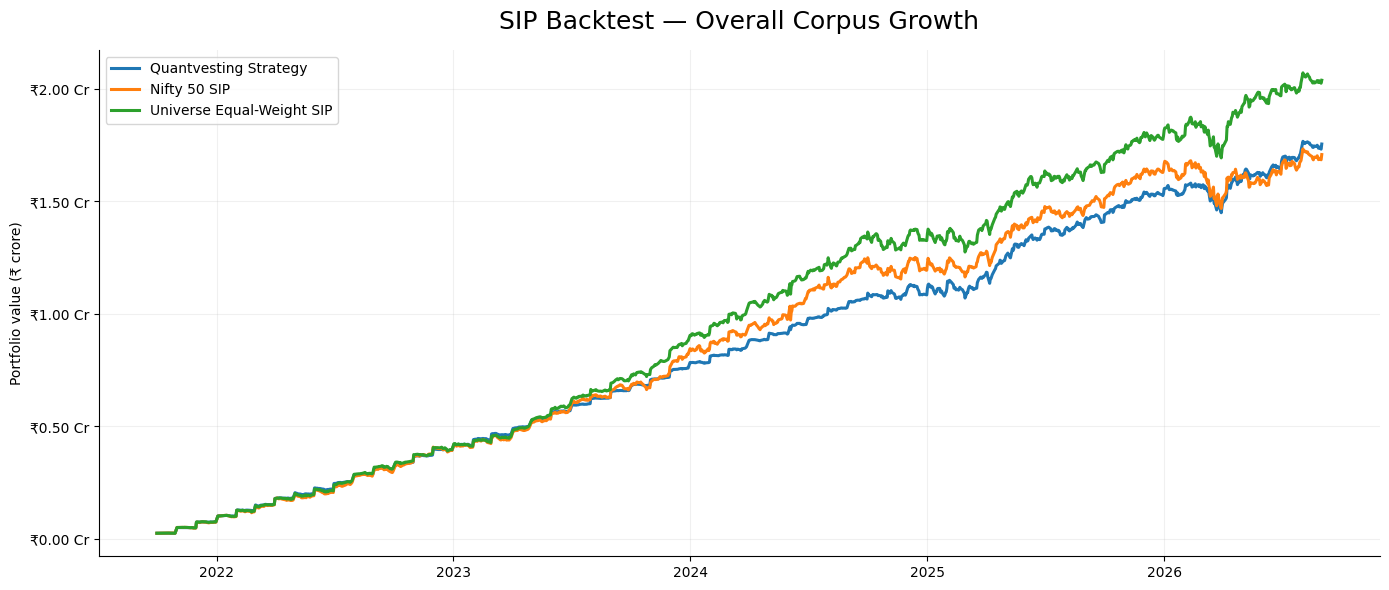

In [10]:
# 10. Overall corpus — all three SIP strategies
paths = pd.concat([
    quant_portfolio.set_index("date")["portfolio_value"].rename("Quantvesting Strategy"),
    nifty_portfolio.set_index("date")["portfolio_value"].rename("Nifty 50 SIP"),
    universe_portfolio.set_index("date")["portfolio_value"].rename("Universe Equal-Weight SIP"),
], axis=1).sort_index().ffill()

fig, ax = plt.subplots(figsize=(14,6))
for col in paths.columns:
    ax.plot(paths.index, paths[col]/1e7, label=col, linewidth=2.2)
ax.set_title("SIP Backtest — Overall Corpus Growth", fontsize=18, pad=15)
ax.set_ylabel("Portfolio value (₹ crore)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x,pos:f"₹{x:.2f} Cr"))
ax.grid(alpha=0.18)
ax.spines[["top","right"]].set_visible(False)
ax.legend()
fig.tight_layout(); plt.show()


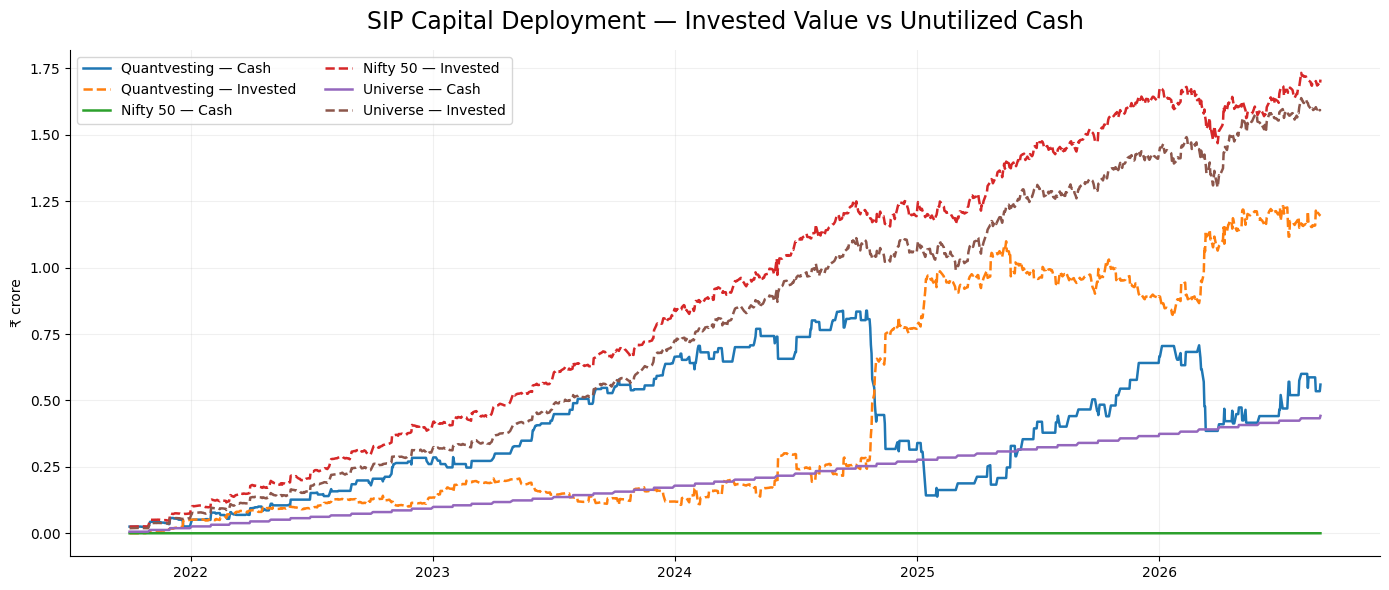

In [11]:
# 11. Invested capital vs unutilized cash — each strategy
fig, ax = plt.subplots(figsize=(14,6))
for p,name in [(quant_portfolio,"Quantvesting"),(nifty_portfolio,"Nifty 50"),(universe_portfolio,"Universe")]:
    ax.plot(p["date"], p["cash"]/1e7, linewidth=1.8, label=f"{name} — Cash")
    ax.plot(p["date"], p["invested_value"]/1e7, linewidth=1.8, linestyle="--", label=f"{name} — Invested")
ax.set_title("SIP Capital Deployment — Invested Value vs Unutilized Cash", fontsize=17, pad=15)
ax.set_ylabel("₹ crore")
ax.grid(alpha=0.18); ax.spines[["top","right"]].set_visible(False); ax.legend(ncol=2)
fig.tight_layout(); plt.show()


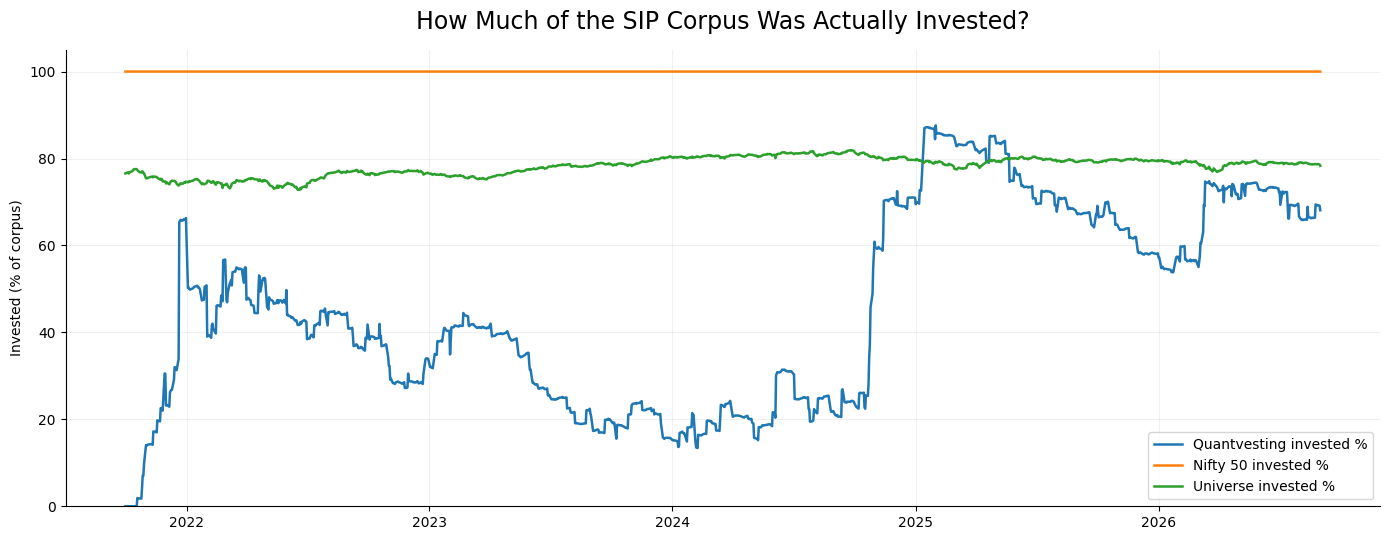

In [12]:
# 12. Percentage of corpus invested vs cash
fig, ax = plt.subplots(figsize=(14,5.5))
for p,name in [(quant_portfolio,"Quantvesting"),(nifty_portfolio,"Nifty 50"),(universe_portfolio,"Universe")]:
    ax.plot(p["date"], p["invested_pct"]*100, linewidth=1.8, label=f"{name} invested %")
ax.set_title("How Much of the SIP Corpus Was Actually Invested?", fontsize=17, pad=15)
ax.set_ylabel("Invested (% of corpus)"); ax.set_ylim(0,105)
ax.grid(alpha=0.18); ax.spines[["top","right"]].set_visible(False); ax.legend()
fig.tight_layout(); plt.show()


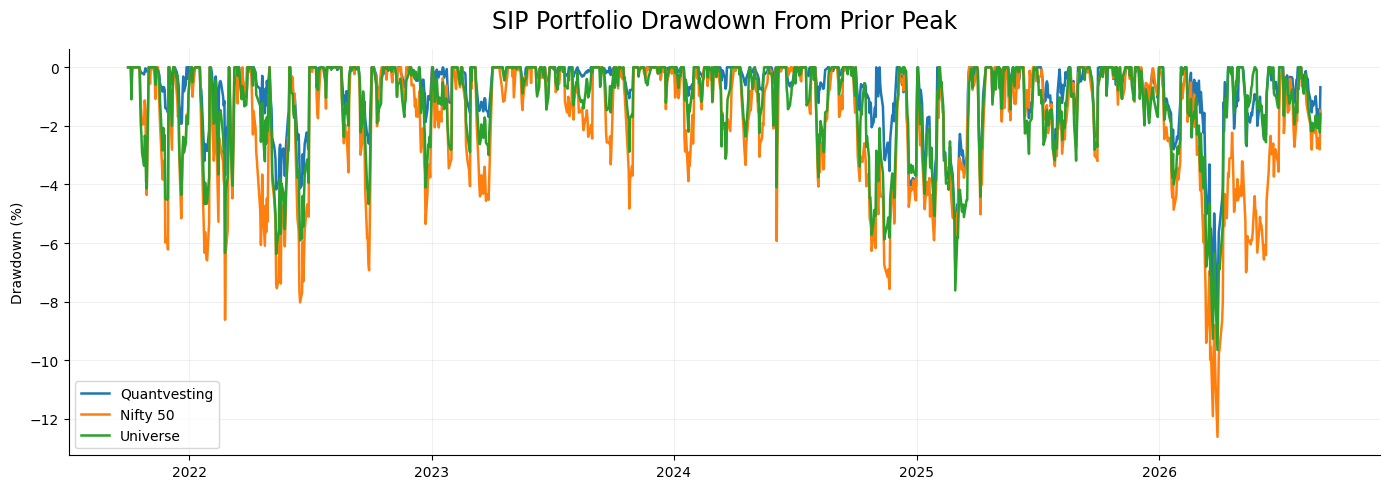

In [13]:
# 13. Drawdown comparison
fig, ax = plt.subplots(figsize=(14,5))
for p,name in [(quant_portfolio,"Quantvesting"),(nifty_portfolio,"Nifty 50"),(universe_portfolio,"Universe")]:
    ax.plot(p["date"], p["drawdown"]*100, linewidth=1.8, label=name)
ax.set_title("SIP Portfolio Drawdown From Prior Peak", fontsize=17, pad=15)
ax.set_ylabel("Drawdown (%)")
ax.grid(alpha=0.18); ax.spines[["top","right"]].set_visible(False); ax.legend()
fig.tight_layout(); plt.show()


In [14]:
# 14. Monthly SIP deployment diagnostics
monthly = pd.DataFrame({"date": sip_dates})
monthly["contribution"] = SIP_AMOUNT

def nearest_value(p, d, col):
    q = p[p["date"] == d]
    return float(q[col].iloc[0]) if not q.empty else np.nan

monthly["Quantvesting Corpus"] = monthly["date"].map(lambda d: nearest_value(quant_portfolio,d,"portfolio_value"))
monthly["Quantvesting Cash"] = monthly["date"].map(lambda d: nearest_value(quant_portfolio,d,"cash"))
monthly["Quantvesting Invested"] = monthly["date"].map(lambda d: nearest_value(quant_portfolio,d,"invested_value"))
monthly["Nifty Corpus"] = monthly["date"].map(lambda d: nearest_value(nifty_portfolio,d,"portfolio_value"))
monthly["Universe Corpus"] = monthly["date"].map(lambda d: nearest_value(universe_portfolio,d,"portfolio_value"))

display(monthly.tail(12).style.format({
    "contribution":"₹{:,.0f}","Quantvesting Corpus":"₹{:,.0f}","Quantvesting Cash":"₹{:,.0f}",
    "Quantvesting Invested":"₹{:,.0f}","Nifty Corpus":"₹{:,.0f}","Universe Corpus":"₹{:,.0f}"
}).hide(axis="index"))


date,contribution,Quantvesting Corpus,Quantvesting Cash,Quantvesting Invested,Nifty Corpus,Universe Corpus
2025-10-01 00:00:00,"₹250,000","₹14,400,151","₹4,448,188","₹9,951,963","₹15,116,894","₹16,642,076"
2025-11-03 00:00:00,"₹250,000","₹15,032,324","₹5,444,390","₹9,587,935","₹15,931,424","₹17,516,422"
2025-12-01 00:00:00,"₹250,000","₹15,415,946","₹6,410,972","₹9,004,974","₹16,434,645","₹18,061,409"
2026-01-01 00:00:00,"₹250,000","₹15,568,438","₹6,660,972","₹8,907,467","₹16,665,682","₹18,161,965"
2026-02-02 00:00:00,"₹250,000","₹15,524,377","₹6,783,729","₹8,740,648","₹16,243,786","₹17,945,285"
2026-03-02 00:00:00,"₹250,000","₹15,738,814","₹7,076,245","₹8,662,569","₹16,351,311","₹18,368,514"
2026-04-01 00:00:00,"₹250,000","₹14,921,177","₹4,103,744","₹10,817,433","₹15,160,865","₹17,474,324"
2026-05-01 00:00:00,"₹250,000","₹16,147,260","₹4,735,875","₹11,411,386",₹nan,"₹19,208,485"
2026-06-01 00:00:00,"₹250,000","₹16,219,821","₹4,411,364","₹11,808,456","₹15,877,700","₹19,624,171"
2026-07-01 00:00:00,"₹250,000","₹16,784,045","₹4,661,364","₹12,122,680","₹16,551,667","₹20,087,128"


## 4. SIP allocation audit

The following checks are designed specifically around the user's 3% rule:

- no Quantvesting entry is larger than 3% of the post-contribution corpus;
- equal-weight universe purchases do not take an individual position above 3% of corpus;
- monthly contributions equal ₹2.5 lakh;
- cumulative contributions equal ₹1.50 crore after 60 SIPs;
- no strategy uses future monthly returns to decide where to allocate the SIP; and
- cash + marked-to-market invested value equals total corpus.


In [15]:
# 15. Audit and trade ledgers
audit = {}
audit["60 monthly contributions"] = len(contributions) == SIP_MONTHS
audit["Total contributed capital = ₹1.50 Cr"] = abs(contributions["contribution"].sum() - SIP_AMOUNT*SIP_MONTHS) < 1e-6 if not contributions.empty else False

q_entries = quant_trades[quant_trades["event"]=="ENTRY"] if not quant_trades.empty else pd.DataFrame()
u_buys = universe_trades if not universe_trades.empty else pd.DataFrame()
audit["Quantvesting 3% entry guardrail"] = bool((q_entries["position_pct_before_entry"] <= MAX_POSITION_PCT + 1e-12).all()) if not q_entries.empty else True
audit["Universe 3% position guardrail"] = bool((u_buys["position_pct"] <= MAX_POSITION_PCT + 1e-12).all()) if not u_buys.empty else True
for name,p in [("Quantvesting",quant_portfolio),("Nifty 50",nifty_portfolio),("Universe",universe_portfolio)]:
    audit[f"{name}: cash never negative"] = bool((p["cash"] >= -1e-7).all())
    audit[f"{name}: cash + invested = corpus"] = bool(np.allclose(p["cash"]+p["invested_value"],p["portfolio_value"],rtol=0,atol=1e-7))

audit_table = pd.DataFrame([{"Audit":k,"Result":"✓ PASS" if v else "✗ FAIL"} for k,v in audit.items()])
display(audit_table.style.hide(axis="index"))

print("\nQuantvesting SIP trade ledger — latest 50 events")
if quant_trades.empty: print("No trades.")
else:
    ql=quant_trades.sort_values(["date","event","symbol"]).tail(50).copy()
    ql["date"]=pd.to_datetime(ql["date"]).dt.strftime("%d %b %Y")
    ql["signal_date"]=pd.to_datetime(ql["signal_date"]).dt.strftime("%d %b %Y")
    ql["price"]=ql["price"].map(lambda x:f"₹{x:,.2f}")
    ql["notional"]=ql["notional"].map(lambda x:f"₹{x:,.0f}")
    ql["position_pct_before_entry"]=ql["position_pct_before_entry"].map(lambda x:f"{x:.2%}" if pd.notna(x) else "")
    display(ql[["date","event","symbol","conviction","rank","price","shares","notional","position_pct_before_entry","reason"]].style.hide(axis="index"))

print("\nUniverse SIP trade ledger — latest 50 purchases")
if universe_trades.empty: print("No trades.")
else:
    ul=universe_trades.sort_values(["date","symbol"]).tail(50).copy()
    ul["date"]=pd.to_datetime(ul["date"]).dt.strftime("%d %b %Y")
    ul["price"]=ul["price"].map(lambda x:f"₹{x:,.2f}")
    ul["notional"]=ul["notional"].map(lambda x:f"₹{x:,.0f}")
    ul["position_pct"]=ul["position_pct"].map(lambda x:f"{x:.2%}")
    display(ul[["date","symbol","price","shares","notional","position_pct"]].style.hide(axis="index"))


Audit,Result
60 monthly contributions,✓ PASS
Total contributed capital = ₹1.50 Cr,✓ PASS
Quantvesting 3% entry guardrail,✓ PASS
Universe 3% position guardrail,✓ PASS
Quantvesting: cash never negative,✓ PASS
Quantvesting: cash + invested = corpus,✓ PASS
Nifty 50: cash never negative,✓ PASS
Nifty 50: cash + invested = corpus,✓ PASS
Universe: cash never negative,✓ PASS
Universe: cash + invested = corpus,✓ PASS



Quantvesting SIP trade ledger — latest 50 events


date,event,symbol,conviction,rank,price,shares,notional,position_pct_before_entry,reason
22 Apr 2025,ENTRY,TCS,X-LC,1,"₹3,324.26",110,"₹365,669",2.99%,Monthly SIP + prior EOD signal → T+1 open
16 May 2025,EXIT,BAJAJHLDNG,X-LC,1,"₹13,231.38",30,"₹396,941",,Frozen entry ATH reached
22 May 2025,EXIT,HDFCAMC,X-LC,1,"₹2,430.78",169,"₹410,802",,Frozen entry ATH reached
22 May 2025,EXIT,HDFCLIFE,X-LC,1,₹760.82,529,"₹402,473",,Frozen entry ATH reached
29 May 2025,ENTRY,ITC,X-LC,1,₹422.21,928,"₹391,812",3.00%,Monthly SIP + prior EOD signal → T+1 open
09 Jun 2025,EXIT,HYUNDAI,X-LC,1,"₹1,969.02",200,"₹393,803",,Frozen entry ATH reached
26 Jun 2025,EXIT,GRASIM,H-LC,2,"₹2,876.31",142,"₹408,436",,Frozen entry ATH reached
09 Jul 2025,ENTRY,BSE,X-LC,1,"₹2,501.25",165,"₹412,706",2.99%,Monthly SIP + prior EOD signal → T+1 open
29 Jul 2025,EXIT,BOSCHLTD,X-LC,1,"₹39,069.26",10,"₹390,693",,Frozen entry ATH reached
04 Aug 2025,ENTRY,SUNPHARMA,H-LC,2,"₹1,630.61",252,"₹410,915",2.99%,Monthly SIP + prior EOD signal → T+1 open



Universe SIP trade ledger — latest 50 purchases


date,symbol,price,shares,notional,position_pct
03 Aug 2026,NESTLEIND,"₹1,510.25",3,"₹4,531",1.66%
03 Aug 2026,PIDILITIND,"₹1,623.81",2,"₹3,248",1.44%
03 Aug 2026,RELIANCE,"₹1,315.86",3,"₹3,948",1.26%
03 Aug 2026,SBILIFE,"₹1,899.95",2,"₹3,800",1.54%
03 Aug 2026,SBIN,"₹1,035.52",4,"₹4,142",1.99%
03 Aug 2026,SIEMENS,"₹3,743.57",1,"₹3,744",1.80%
03 Aug 2026,SUNPHARMA,"₹1,984.19",2,"₹3,968",1.89%
03 Aug 2026,TATACONSUM,"₹1,085.54",4,"₹4,342",1.47%
03 Aug 2026,TCS,"₹2,385.09",2,"₹4,770",0.71%
03 Aug 2026,TMPV,₹344.67,13,"₹4,481",0.84%


# 5. Interpretation framework

The notebook intentionally does **not** declare a strategy “best” using a single metric. For a SIP investor, the useful comparison is:

1. **Ending corpus** — how much the monthly contributions became.
2. **Profit over ₹1.50 Cr contributed** — absolute wealth created.
3. **XIRR** — a money-weighted return appropriate for staggered contributions.
4. **Maximum drawdown** — depth of the worst decline from a prior portfolio peak.
5. **Average invested % / cash %** — how much of the SIP corpus was actually deployed.
6. **Final unutilized cash** — capital that never found an eligible opportunity.
7. **Trade count and transaction costs** — operational overhead.
8. **3% guardrail compliance** — whether the requested position-sizing rule was actually respected.

### A particularly important diagnostic

Because this is a SIP rather than a ₹1 crore lump-sum investment, **ending corpus alone is not enough**. The timing of contributions matters. XIRR and the corpus-vs-contributed-capital curve should therefore be read together.

### No hindsight allocation

The notebook deliberately avoids selecting the stock that subsequently delivered the highest return during a month. Such an allocation would answer a different question and would introduce look-ahead bias. Instead, “most lucrative opportunity” is implemented using information available at the decision point.


In [16]:
# 16. Final decision dashboard
rows=[]
for name,p in [("Quantvesting Strategy",quant_portfolio),("Nifty 50 SIP",nifty_portfolio),("Universe Equal-Weight SIP",universe_portfolio)]:
    m=sip_metrics(p)
    rows.append({
        "Approach":name, "Total SIP":m["Contributed Capital"], "Ending Corpus":m["Ending Corpus"],
        "Profit":m["Profit"], "XIRR":m["XIRR"], "Max Drawdown":m["Max Drawdown"],
        "Avg Invested %":m["Average Invested %"], "Avg Cash %":m["Average Cash %"], "Final Cash":m["Final Cash"]
    })
summary=pd.DataFrame(rows)
display(summary.style.format({
    "Total SIP":"₹{:,.0f}","Ending Corpus":"₹{:,.0f}","Profit":"₹{:,.0f}","XIRR":"{:.2%}",
    "Max Drawdown":"{:.2%}","Avg Invested %":"{:.2%}","Avg Cash %":"{:.2%}","Final Cash":"₹{:,.0f}"
}).hide(axis="index"))

print("\nHistorical SIP comparison only: this notebook describes what the three rules would have produced under the stated assumptions. It is not a forecast or investment recommendation.")


Approach,Total SIP,Ending Corpus,Profit,XIRR,Max Drawdown,Avg Invested %,Avg Cash %,Final Cash
Quantvesting Strategy,"₹15,000,000","₹17,548,223","₹2,548,223",6.42%,-8.32%,45.87%,54.13%,"₹5,597,429"
Nifty 50 SIP,"₹14,750,000","₹17,079,882","₹2,329,882",5.91%,-12.61%,100.00%,-0.00%,₹0
Universe Equal-Weight SIP,"₹15,000,000","₹20,382,645","₹5,382,645",12.61%,-9.65%,78.23%,21.77%,"₹4,420,286"



Historical SIP comparison only: this notebook describes what the three rules would have produced under the stated assumptions. It is not a forecast or investment recommendation.
